In [1]:
# HW01: Настройка окружения и основы NumPy/Pandas
# Захар Житко

In [2]:
## 1. Проверка окружения

In [3]:
import sys, numpy, pandas, sklearn
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {numpy.__version__}")
print(f"Pandas: {pandas.__version__}")
print(f"sklearn: {sklearn.__version__}")

Python: 3.11.14
NumPy: 2.4.2
Pandas: 3.0.1
sklearn: 1.8.0


In [4]:
## 2. Работа с NumPy

In [5]:
import numpy as np
np.random.seed(42)
X = np.random.rand(100, 5)
print(f"Вся матрица — mean: {X.mean():.3f}, std: {X.std():.3f}")
print(f"По столбцам — mean:\n{X.mean(axis=0)}")
w = np.array([1, 2, 3, 4, 5])
y = X @ w
print(f"Результат y.shape: {y.shape}")

Вся матрица — mean: 0.499, std: 0.298
По столбцам — mean:
[0.50471071 0.52523233 0.48769797 0.52125415 0.45391341]
Результат y.shape: (100,)


In [6]:
## 3. Работа с Pandas

In [7]:
import pandas as pd
df = pd.DataFrame(X, columns=[f'feature_{i+1}' for i in range(5)])
df['target'] = y
print(df.head(100))
print(f"\nShape: {df.shape}")
print(f"\nDescribe:\n{df.describe()}")
print(f"\nПропуски:\n{df.isnull().sum()}")
print(f"\nСтроки где feature_1 > 0.5:\n{df[df['feature_1'] > 0.5].head()}")
df_sorted_asc = df.sort_values('feature_1')
print(f"\nСортировка по столбцу feature_1 (возрастание): \n{df_sorted_asc.head(10)}")
df_sorted_desc = df.sort_values('feature_1', ascending=False)
print(f"\nСортировка по столбцу feature_1 (убывание): \n{df_sorted_desc.head(10)}")
df_groupby_target = df.groupby('target')
print(f"\nГруппировка по различным значениям встолбце target: \n{df_groupby_target.head(30)}")

    feature_1  feature_2  feature_3  feature_4  feature_5     target
0    0.374540   0.950714   0.731994   0.598658   0.156019   7.646678
1    0.155995   0.058084   0.866176   0.601115   0.708073   8.815513
2    0.020584   0.969910   0.832443   0.212339   0.181825   6.216213
3    0.183405   0.304242   0.524756   0.431945   0.291229   5.550084
4    0.611853   0.139494   0.292145   0.366362   0.456070   5.513072
..        ...        ...        ...        ...        ...        ...
95   0.992965   0.073797   0.553854   0.969303   0.523098   9.294820
96   0.629399   0.695749   0.454541   0.627558   0.584314   8.816323
97   0.901158   0.045446   0.280963   0.950411   0.890264  10.087905
98   0.455657   0.620133   0.277381   0.188121   0.463698   5.599042
99   0.353352   0.583656   0.077735   0.974395   0.986211  10.582501

[100 rows x 6 columns]

Shape: (100, 6)

Describe:
        feature_1   feature_2   feature_3   feature_4   feature_5      target
count  100.000000  100.000000  100.000000 

In [8]:
## 4. Визуализация

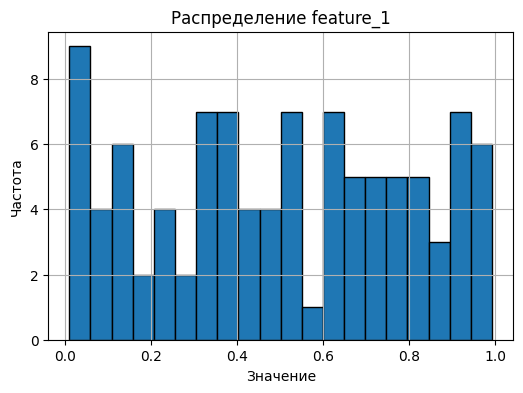

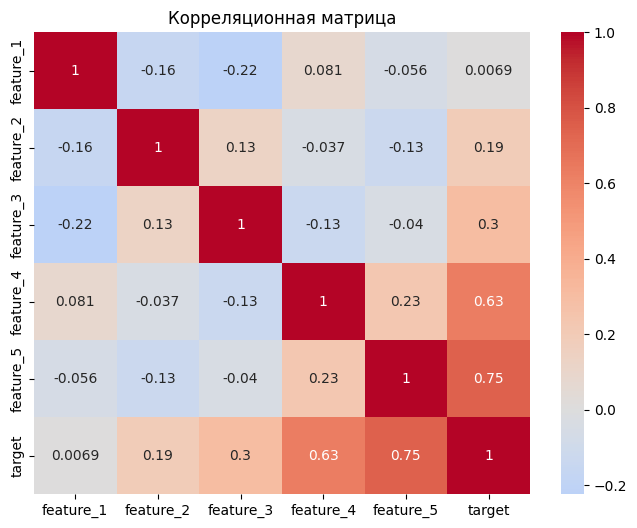

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
df['feature_1'].hist(bins=20, edgecolor='black')
plt.title('Распределение feature_1')
plt.xlabel('Значение')
plt.ylabel('Частота')
plt.show()
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

In [10]:
## 5. Бонус (классификация цветков по 4 признакам на 3 класса)

Ключи в объекте iris: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Описание датасета:
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high

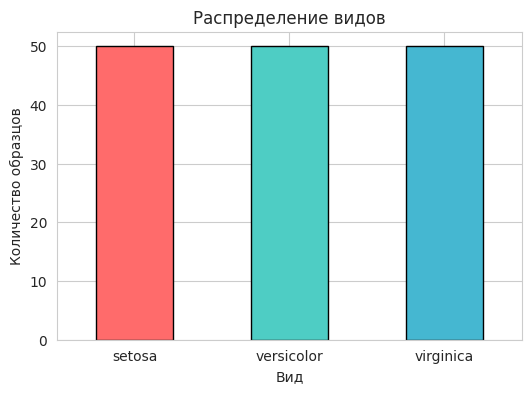

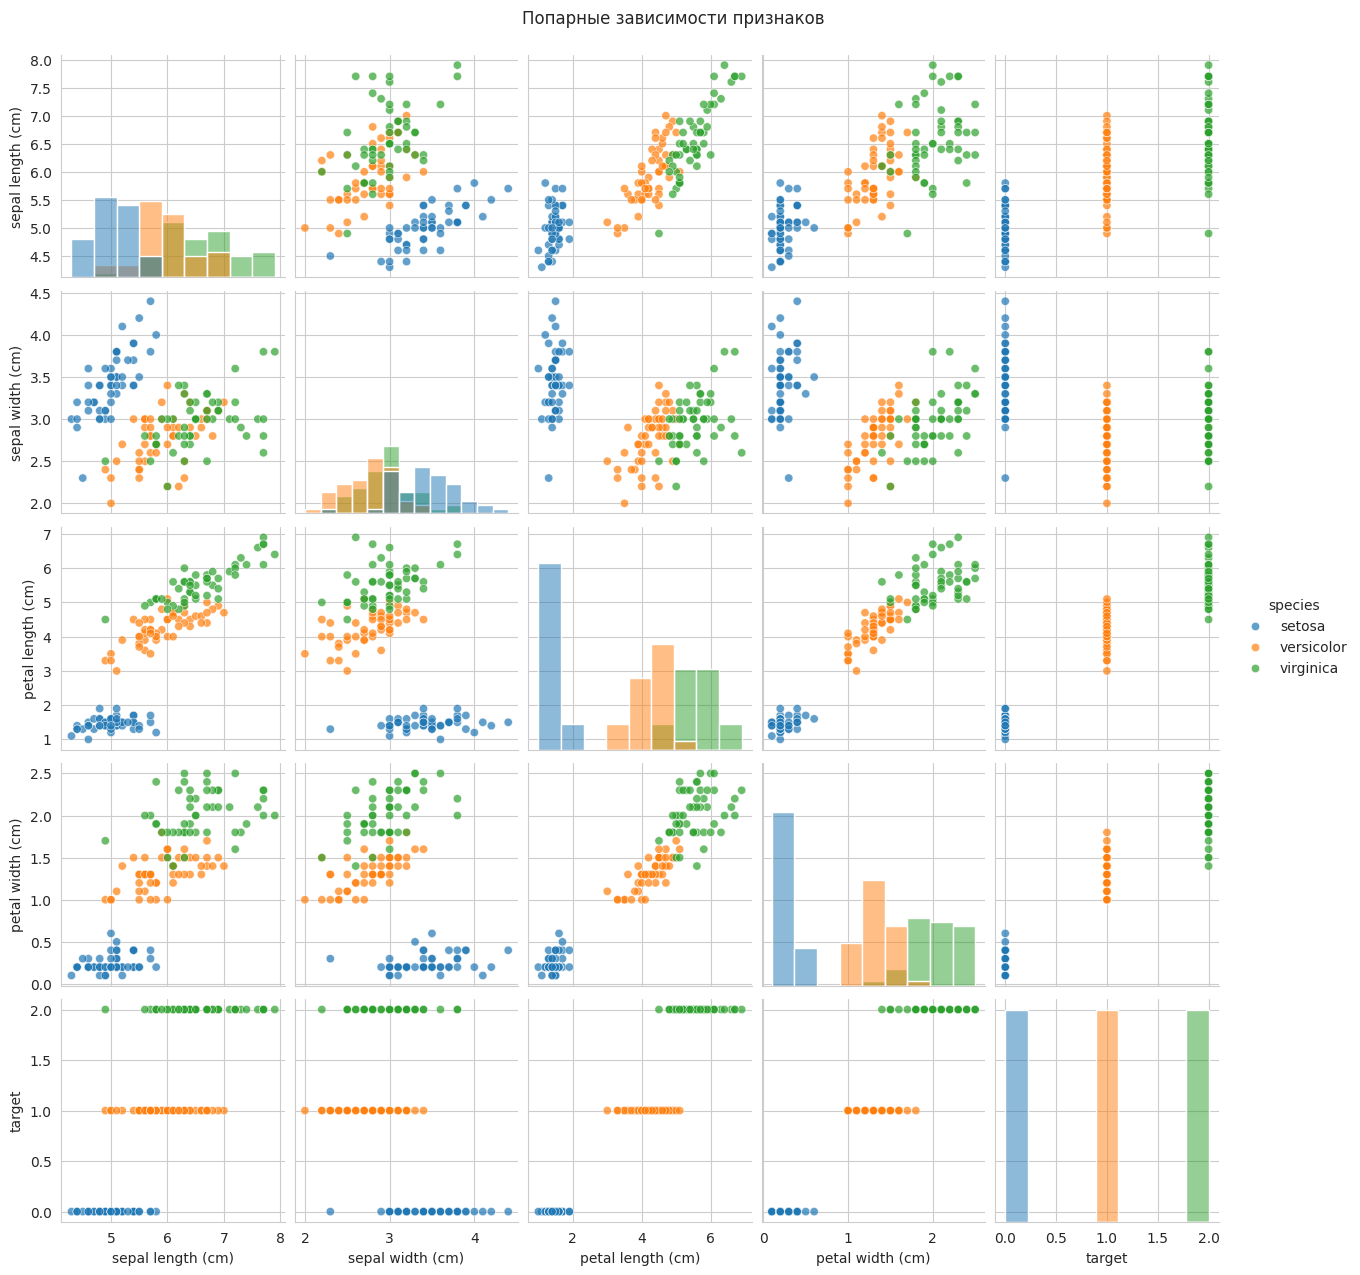

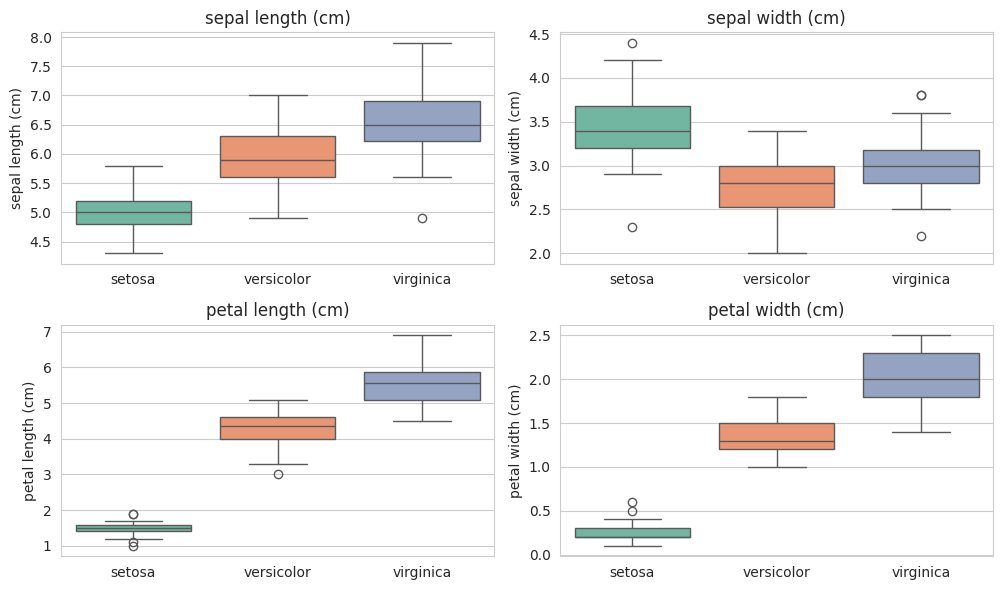


Размер обучающей выборки: (120, 4)
Размер тестовой выборки: (30, 4)

Модель обучена!
Веса модели
[[-5.29619995e-01  8.27358123e-01 -2.34726315e+00 -9.93463481e-01]
 [ 5.29726953e-01 -3.04865937e-01 -1.70965141e-01 -8.56157878e-01]
 [-1.06957382e-04 -5.22492185e-01  2.51822829e+00  1.84962136e+00]]
Свободный член: [ 10.12541553   1.79802823 -11.92344376]

Accuracy: 0.967 (96.7%)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



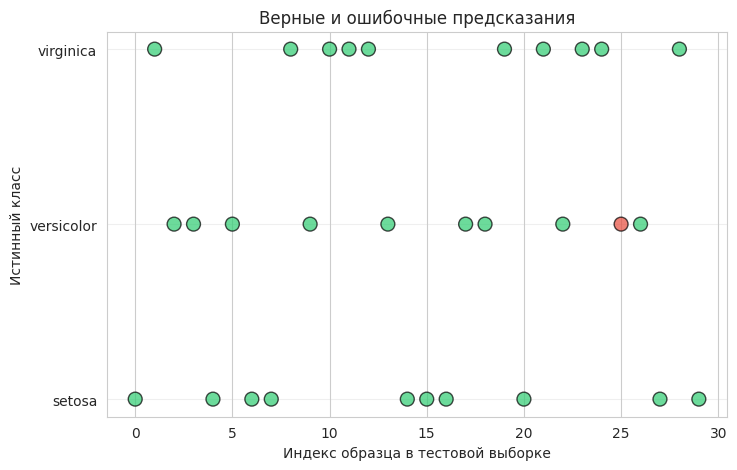

In [11]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()

print(f"Ключи в объекте iris: {iris.keys()}")
print(f"Описание датасета:\n{iris.DESCR[:1500]}...")

X_iris = iris.data
y_iris = iris.target

print(f"\nФорма данных: {X_iris.shape}")
print(f"Форма меток: {y_iris.shape}")
print(f"Названия классов: {iris.target_names}")
print(f"Названия признаков: {iris.feature_names}")
df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris['target'] = y_iris
df_iris['species'] = df_iris['target'].map({
    0: 'setosa', 
    1: 'versicolor', 
    2: 'virginica'
})

print("\nDataFrame:")
print(df_iris.head(150))

print(f"\nInfo")
print(df_iris.info())

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
df_iris['species'].value_counts().sort_index().plot(
    kind='bar', 
    color=['#FF6B6B', '#4ECDC4', '#45B7D1'],
    edgecolor='black'
)
plt.title('Распределение видов')
plt.xlabel('Вид')
plt.ylabel('Количество образцов')
plt.xticks(rotation=0)
plt.show()

sns.pairplot(df_iris, hue='species', diag_kind='hist', 
             plot_kws={'alpha': 0.7}, height=2.5)
plt.suptitle('Попарные зависимости признаков', y=1.02)
plt.show()

plt.figure(figsize=(10, 6))
for i, feature in enumerate(iris.feature_names):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=df_iris, x='species', y=feature, 
                hue='species', palette='Set2', legend=False)
    plt.title(feature)
    plt.xlabel('')
plt.tight_layout()
plt.show()

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, 
    test_size=0.2,
    random_state=42,
    stratify=y_iris
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
print(f"\nМодель обучена!")
print(f"Веса модели\n{model.coef_}")
print(f"Свободный член: {model.intercept_}")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))
plt.figure(figsize=(8, 5))
colors = ['#2ECC71' if pred == true else '#E74C3C' for pred, true in zip(y_pred, y_test)]
plt.scatter(range(len(y_test)), y_test, c=colors, s=100, edgecolors='black', alpha=0.7)
plt.xlabel('Индекс образца в тестовой выборке')
plt.ylabel('Истинный класс')
plt.title('Верные и ошибочные предсказания')
plt.yticks([0, 1, 2], iris.target_names)
plt.grid(axis='y', alpha=0.3)
plt.show()